# 053 — Design-group collapse fragilities in AvgSA (group-aware replacement for `014`)

Re-express the IDA-based **collapse fragilities** of the EC8-gen2 case-study CBFs from
their native **SA(T1)** into **AvgSA_03** (0–3 s) and **AvgSA_06** (0–6 s), exactly as
notebook `014` does — but reading the **per-design-group** FEMA P695 IDAs written by
`052` instead of the 60 per-site IDAs.

Notebook `051` showed the 120 (site, storey) designs collapse to **51 unique designs**
(25 × 3s, 26 × 5s). The IDA depends only on the structure (the 22 FEMA P695 records are
fixed), so one IDA per group is enough: `052` runs
`D:/08_wp1_fixed_record_sets/group_{n}s_{gid}/{n}s/mdof/ida_femap695/`, and this notebook

1. converts **each group's** IDA once (SA, AvgSA_03, AvgSA_06), caching the result under
   `data_processed/09_structure_fragility_curves/wp1_design_groups/group_{n}s_{gid}/`, and
2. **fans that fragility back out** to every member site as
   `wp1_casestudy_sites/site_{ii}/{tag}_ida_femap695_collapsefragility_{im}.json`
   — exactly the filenames `014` wrote.

§8 additionally exports the **raw material of those fits**: the per-record collapse
capacities, cached per group next to each fragility and collected into one
group × record table per IM (`group_femap695_collapse_imls_{SA,AvgSA_03}.csv`, in g). A
fragility is only a two-number summary of those 22 capacities; keeping them means a curve
can be re-fitted, bootstrapped or compared record-by-record against the MSA results
without going back to `D:`.

Step 2 is what makes this a drop-in replacement: `054` (stripe IMLs from the
representative's AvgSA_03 fragility) and `061`
(`msa_ida_hypothesis_testing.load_site_fragility_curves`) read those per-site paths and
need no change at all.

`014` is left in place for now but nothing here depends on it: this notebook does not read
it, does not delete it, and does not touch its figures or its summary CSV. It *does*
rewrite the per-site fragility JSONs, which are `014`'s output as much as `053`'s.

## Why the output is the same — a one-off check, not a fixture

The conversion machinery is identical to `014` (`convert_ida_collapse_imls` +
`fragility_from_ida`, `g_factor = 1/GRAVITY`). The only question is whether *one* IDA per
group may stand in for the per-site IDAs, and **§2, §3 and §6 answer it once**:

- **§3 — from the per-site fragilities already on disk, no IDA results needed.** Within
  every 3s design group, the 60 fragilities `014` wrote agree to machine precision
  (largest relative spread ~1e-16 in both median and dispersion, all three IMs). The sites
  in a group really do carry one and the same fragility, so collapsing them loses nothing.
- **§6 — against the baseline read in §2.** After the fan-out, every per-site file is
  compared with the value it replaced and the largest relative difference is reported.

Those three sections are gated on `COMPARE_WITH_NB014` and are **meant to be deleted**
once they have passed — they are only meaningful on the first run, while the files on disk
are still `014`'s. Everything from §4 on stands alone.

There is a third, free check while `052`'s migration is fresh: for the 3s groups whose
results were *migrated* (a byte copy of the representative site's IDA folder),
`cache_utils.fingerprint` is content-based, so the group conversion sees exactly the hashes
`014`'s manifests recorded — those files come back as `cached`.

## Inputs

- `D:/08_wp1_fixed_record_sets/group_{n}s_{gid}/{n}s/mdof/ida_femap695/` — the group IDAs
  (`ida_results.pickle`, `record_logs.json`, `record_*/ida_result_record_*.pickle`), `052`.
- `unique_structural_designs.csv` (nb `051`) — the (site, storey) → group table.
- `results/06_group_ida_femap695/group_folder_map.csv` (nb `052`) — cross-checked, not required.
- `ec8_gen2_site_specific_cbfs.pickle` (nb `011`) — structure names and `Vb_coeff`.

## Outputs

| Path | Content |
|---|---|
| `…/09_structure_fragility_curves/wp1_design_groups/group_{n}s_{gid}/group_{n}s_{gid}_ida_femap695_collapsefragility_{im}.json` | the group conversion (+ manifest) |
| `…/09_structure_fragility_curves/wp1_casestudy_sites/site_{ii}/{tag}_ida_femap695_collapsefragility_{im}.json` | the per-site copy `014` used to write (+ manifest) |
| `…/wp1_design_groups/group_femap695_collapsefragility_summary.csv` | group-level median/β table |
| `…/wp1_design_groups/group_femap695_collapse_imls_{SA,AvgSA_03}.csv` | the per-record collapse capacities the fits are built from, one group × record table per IM, in g |
| `…/wp1_casestudy_sites/site_femap695_collapsefragility_summary_from_groups.csv` | site-level table (`014`'s CSV is left alone unless `OVERWRITE_SITE_SUMMARY = True`) |
| `results/06_group_ida_femap695/*.png` | the three figures (`014`'s PNGs are left alone) |

> **Run order.** `011` → `051` → `052` (+ the IDA runs) → **053** → `054`, `060`, `061`.
> The IDA results live on `D:` — run this on the workstation. Without the drive the
> notebook still runs §1–§3 (the grouping check) and then reports that nothing could be
> converted.

## Open questions, and the assumption taken for each

Written down for review — every one of these was decided here, not asked.

| # | Question | Assumption taken | If it is wrong |
|---|---|---|---|
| 1 | Should `053` write per-**group** fragility files, or per-**site** ones? | **Both.** The group file is the cached artefact; it is then copied to every member site under the exact `014` filename. Otherwise `054`/`061` would have to learn about groups. | Set `FANOUT_TO_SITES = False` to write only the group files, and teach the downstream notebooks the group map. |
| 2 | May `053` overwrite `014`'s per-site JSONs? | **Yes**, in place and with no backup kept. They are the files `054`/`061` read, so they have to be current, and `053` reproduces them exactly (§6). | Point `OUT_ROOT` at a scratch folder for a dry run first. |
| 2b | Should the comparison against `014` stay in the notebook? | **No** — §2/§3/§6 are gated on `COMPARE_WITH_NB014` and are there for the first run only. Once they pass, set it `False` or delete those three sections; they read the per-site files as a "baseline", which after the first `053` run is just `053`'s own previous output. | — |
| 3 | …and `014`'s summary CSV and PNGs? | **No.** The CSV goes to `…_summary_from_groups.csv` and the figures to `results/06_group_ida_femap695/`, so `014`'s outputs survive for comparison. | Set `OVERWRITE_SITE_SUMMARY = True` once you are happy. |
| 4 | Which storey counts? | **3 and 5.** `014` did 3s only (the 5s IDAs had not been run); `052` sets up both, so both are converted here. 5s simply has no `014` baseline for §6 to compare against. | Edit `STOREYS`. |
| 5 | Where does the group's `T1` come from? | The group IDA's own record logs (`intensity_measure=…period=…`), exactly as in `014`. One structure per group, so one `T1`. | — |
| 6 | What should the per-site copies fingerprint? | The **group fragility JSON** (plus group name / site / storeys), not the raw IDA — a site file is stale exactly when its group conversion changed. This is a different provenance chain from `014`'s (which named `ida_results.pickle`), so the first run of `053` rewrites every per-site file even where the value is unchanged. | — |
| 7 | Non-representative member sites still have their own per-site IDA folders under `D:/07_wp1_casestudy_sites`. Should those be used at all? | **No** — ignored entirely. §3 shows they carry the same fragility as their group. | — |
| 8 | `052`'s group map currently lists `needs_run = True` for every group. Should a missing group IDA be an error? | **No** — reported and skipped, as `014` did for sites without IDA output, so the notebook stays useful while the runs trickle in. | Set `STRICT = True` to raise instead. |
| 10 | Which IMs get a per-record capacity table, and in what units? | **SA and AvgSA_03 only**, in **g** — the values `fragility_from_ida` actually fits (`g_factor = 1/GRAVITY`), so they are consistent with the medians in the summary CSVs. AvgSA_06 keeps its fragility but gets no table; nothing downstream asks for its per-record capacities. | Add `"AvgSA_06"` to `IML_TABLE_IMS`. |
| 11 | What identifies a record in those tables? | The **record tag** — the `collect_ida_results` key, i.e. the `record_{tag}` folder suffix (`00`…`21`) — as the column header, so a column means the same record in every row and in the IDA folders on disk. | — |
| 12 | A group whose IDA is missing some records? | **Reported, not an error**: the row is short and the absent records are `NaN`, consistent with §4 tolerating a group that is still running. Such a group's fragility is fitted from fewer records, which §4 already warns about. | — |
| 9 | Should `053` also re-derive `Vb_coeff`? | **No** — read from the `011` site dataset, as `014` did. The plots colour each *site* by its own `Vb_coeff`; sites in a group share a design, so they share it anyway. | — |

## 0. Setup & parameters

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.stats import lognorm

from phd_project.config import config
from phd_project.scripts.cache_utils import fingerprint, json_load_or_compute
from phd_project.scripts.WP1_ground_motion_set.design_groups import load_design_groups
from standes.analysis.ida import (
    collect_ida_results, collect_record_logs, get_collapse_iml,
    convert_ida_collapse_imls
)
from standes.fragility_curves import fragility_from_ida
from standes.fitting import lognorm_moment_fit
from standes.intensitymeasures import SpectralAcceleration, avgsa_03, avgsa_06
from standes.groundmotion import load_ground_motion_from_json

cfg = config.load_config()

In [11]:
# ----------------------------------------------------------------------------
# PARAMETERS
# ----------------------------------------------------------------------------
# Root of the per-DESIGN-GROUP analysis folders written by nb 052. Per group the FEMA
# P695 IDA lives at GROUP_ROOT/group_{n}s_{gid}/{n}s/mdof/ida_femap695/.
GROUP_ROOT = Path(cfg["analysis_data"]["wp1_fixed_record_sets"])

# nb 052's group -> member-site map. Cross-checked against nb 051's table; not required.
GROUP_MAP_PATH = Path(cfg["results"]["group_ida_femap695"]) / "group_folder_map.csv"

# Site dataset (nb 011): structure names and the design base-shear coefficient Vb_coeff.
SITE_DATASET = Path(cfg["proc_data"]["site_specific_dataset"])

STOREYS = [3, 5]

# --- outputs ---
# The group conversion (the cached artefact).
GROUP_OUT_ROOT = Path(cfg["proc_data"]["wp1_groups_fragility_curves"])
# The per-site copies - the same files nb 014 writes, read by nb 054 / 061.
OUT_ROOT = Path(cfg["proc_data"]["wp1_sites_fragility_curves"])
# Figures. Deliberately NOT nb 014's folder, so its PNGs survive.
FIG_ROOT = Path(cfg["results"]["group_ida_femap695"])

for _d in (GROUP_OUT_ROOT, OUT_ROOT, FIG_ROOT):
    _d.mkdir(parents=True, exist_ok=True)

# Copy the group fragility out to every member site under nb 014's filenames. False
# writes only the group-level files (nothing downstream would then find its fragility).
FANOUT_TO_SITES = True

OVERWRITE_SITE_SUMMARY = True

# Raise instead of skipping when a group has no IDA output on disk.
STRICT = False

# Force a full re-conversion even when the provenance manifest still matches.
FORCE_RECOMPUTE = False

# IML units of the IDA [mm/s^2]. Every fragility written here is rescaled by 1/GRAVITY
# so all medians and empirical curves are a fraction of g. Same as nb 014.
GRAVITY = 9810.0

# Target intensity measures (SA(T1) is handled separately as the native IM).
AVGSA_IMS = {"AvgSA_03": avgsa_03(), "AvgSA_06": avgsa_06()}
IM_ORDER = ["SA", "AvgSA_03", "AvgSA_06"]  # panel / column order

IDA_TAG = "ida_femap695"

# Summary CSVs. Derived from the roots above rather than read straight from the config,
# so pointing OUT_ROOT / GROUP_OUT_ROOT at a scratch folder keeps a dry run entirely
# self-contained. The filenames are the config's.
GROUP_SUMMARY_CSV = GROUP_OUT_ROOT / Path(
    cfg["proc_data"]["wp1_groups_femap695_fc_summary"]).name
_site_csv = Path(cfg["proc_data"]["wp1_sites_femap695_fc_summary"])
SITE_SUMMARY_CSV = OUT_ROOT / (_site_csv.name if OVERWRITE_SITE_SUMMARY
                               else _site_csv.stem + "_from_groups.csv")

# Per-record collapse capacity tables (section 8): one CSV per IM, a group x record
# matrix in units of g. Only these IMs get a per-record table - AvgSA_06 keeps its
# fragility only. The filename is the config's stem plus the IM.
IML_TABLE_IMS = ["SA", "AvgSA_03"]
_iml_csv = Path(cfg["proc_data"]["wp1_groups_femap695_collapse_imls"])
IML_CSV = {im: GROUP_OUT_ROOT / f"{_iml_csv.stem}_{im}.csv" for im in IML_TABLE_IMS}

# --- collapse-bracket variants (section 10) ---------------------------------------
# The fragilities above take each record's collapse capacity to be the top of its IDA
# curve - the highest intensity that produced a result, i.e. the LOWER bound of the
# bracket the IDA actually leaves. The run logs also carry the lowest intensity that
# collapsed (the upper bound); the geometric mean of the two is the log-midpoint of the
# bracket. Section 10 publishes those two variants for AvgSA_03 only: summaries and
# per-record capacity tables, no fragility JSONs (see nb 074 section 2 for why).
BRACKET_IM = "AvgSA_03"
BRACKET_VARIANTS = ["ub", "avg"]          # "lb" is the published fragility above
BRACKET_LABEL = {v: f"{BRACKET_IM}_{v}" for v in BRACKET_VARIANTS}

BRACKET_GROUP_SUMMARY_CSV = (GROUP_OUT_ROOT
                             / "group_femap695_bracket_collapsefragility_summary.csv")
BRACKET_SITE_SUMMARY_CSV = (OUT_ROOT
                            / "site_femap695_bracket_collapsefragility_summary.csv")
BRACKET_IML_CSV = {v: GROUP_OUT_ROOT / f"{_iml_csv.stem}_{BRACKET_IM}_{v}.csv"
                   for v in BRACKET_VARIANTS}

print(f"GROUP_ROOT     = {GROUP_ROOT}")
print(f"GROUP_OUT_ROOT = {GROUP_OUT_ROOT}")
print(f"OUT_ROOT       = {OUT_ROOT}  (fan-out: {FANOUT_TO_SITES})")
print(f"FIG_ROOT       = {FIG_ROOT}")

GROUP_ROOT     = D:\08_wp1_fixed_record_sets
GROUP_OUT_ROOT = C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups
OUT_ROOT       = C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_casestudy_sites  (fan-out: True)
FIG_ROOT       = C:\Users\clemettn\Documents\phd\results\06_group_ida_femap695


## 1. Design groups and their IDA folders

One row per design group from `051` (`is_representative == True`), with its member sites.
The folder convention is `052`'s: `GROUP_ROOT/group_{n}s_{gid:02d}/{n}s/mdof/ida_femap695`.

Three checks run here:

- every group is non-empty and every (site, storey) belongs to exactly one group;
- the member lists cover every site of each storey count in `STOREYS`;
- the derived folders agree with `052`'s `group_folder_map.csv` when that file exists (it
  is written in-repo, so this check works with the analysis drive detached).

In [12]:
groups_df = load_design_groups(cfg)
groups_df = groups_df[groups_df["storeys"].isin(STOREYS)].copy()

groups = (groups_df[groups_df["is_representative"]]
          .loc[:, ["storeys", "group_id", "representative_site", "representative_tag",
                   "n_sites_in_group"]]
          .sort_values(["storeys", "group_id"])
          .reset_index(drop=True))

members = (groups_df.groupby(["storeys", "group_id"])["site"]
           .apply(lambda s: sorted(int(x) for x in s)))


def group_folder_name(n: int, gid: int) -> str:
    """Folder for a design group: group_3s_00, group_5s_07, ... (nb 052's convention)."""
    return f"group_{int(n)}s_{int(gid):02d}"


def group_ida_folder(n: int, gid: int, ida_tag: str = IDA_TAG) -> Path:
    return GROUP_ROOT / group_folder_name(n, gid) / f"{int(n)}s" / "mdof" / ida_tag


# --- sanity checks on the grouping itself ---
dupes = int(groups_df.duplicated(subset=["storeys", "site"]).sum())
assert dupes == 0, f"{dupes} (site, storey) pairs appear in more than one group"
assert (groups["n_sites_in_group"] > 0).all(), "a group has no member sites"

for n in STOREYS:
    all_sites = sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
    from_members = sorted(s for gid in groups.loc[groups["storeys"] == n, "group_id"]
                          for s in members[(n, int(gid))])
    assert from_members == all_sites, f"{n}s: member lists do not cover every site once"
    print(f"{n}s: {int((groups['storeys'] == n).sum()):2d} design groups covering "
          f"{len(all_sites)} sites (site {min(all_sites)}..{max(all_sites)})")

groups["ida_folder"] = [group_ida_folder(r.storeys, r.group_id)
                        for r in groups.itertuples()]
groups["ida_exists"] = [p.is_dir() for p in groups["ida_folder"]]
print(f"\n{int(groups['ida_exists'].sum())}/{len(groups)} group(s) have IDA output on disk")
if not GROUP_ROOT.exists():
    print(f"NOTE: {GROUP_ROOT} is not reachable - the analysis drive is detached, so "
          f"nothing can be converted in this run.")
groups.head()

3s: 25 design groups covering 60 sites (site 0..59)
5s: 26 design groups covering 60 sites (site 0..59)

51/51 group(s) have IDA output on disk


,storeys,group_id,representative_site,representative_tag,n_sites_in_group,ida_folder,ida_exists
0,3,0,0,3s_cbf_dc2_site0,8,D:\08_wp1_fixed_record_sets\group_3s_00\3s\mdo...,True
1,3,1,1,3s_cbf_dc2_site1,6,D:\08_wp1_fixed_record_sets\group_3s_01\3s\mdo...,True
2,3,2,3,3s_cbf_dc2_site3,1,D:\08_wp1_fixed_record_sets\group_3s_02\3s\mdo...,True
3,3,3,7,3s_cbf_dc2_site7,5,D:\08_wp1_fixed_record_sets\group_3s_03\3s\mdo...,True
4,3,4,9,3s_cbf_dc2_site9,3,D:\08_wp1_fixed_record_sets\group_3s_04\3s\mdo...,True


In [13]:
# --- cross-check the derived folders against nb 052's group map ---
if not GROUP_MAP_PATH.is_file():
    print(f"no group map at {GROUP_MAP_PATH} (nb 052 not run here) - skipping cross-check")
else:
    gmap = pd.read_csv(GROUP_MAP_PATH)
    gmap = gmap[gmap["storeys"].isin(STOREYS)]
    mapped = {(int(r.storeys), int(r.group_id)): r for r in gmap.itertuples()}
    mismatch = []
    for r in groups.itertuples():
        key = (int(r.storeys), int(r.group_id))
        m = mapped.get(key)
        if m is None:
            mismatch.append(f"{group_folder_name(*key)}: absent from the group map")
            continue
        # nb 052 stores the mdof folder; the IDA folder is that + the ida_tag.
        expect = (Path(m.folder) / m.ida_tag).as_posix().lower()
        if Path(r.ida_folder).as_posix().lower() != expect:
            mismatch.append(f"{group_folder_name(*key)}: {r.ida_folder} != {expect}")
        if int(m.representative_site) != int(r.representative_site):
            mismatch.append(f"{group_folder_name(*key)}: representative site differs")
        if sorted(int(s) for s in str(m.sites).split()) != members[key]:
            mismatch.append(f"{group_folder_name(*key)}: member sites differ")
    if mismatch:
        raise AssertionError("group map disagrees with nb 051's table:\n  "
                             + "\n  ".join(mismatch))
    print(f"group map agrees with nb 051 for all {len(groups)} group(s): folders, "
          f"representatives and member lists")

group map agrees with nb 051 for all 51 group(s): folders, representatives and member lists


In [14]:
# --- structure names and design base-shear coefficients (nb 011), for the plots ---
designs = pd.read_pickle(SITE_DATASET)
designs = designs[designs["n_storeys"].isin(STOREYS)].copy()

NAME = {(int(r.n_storeys), int(r.site_idx)): r.structure_name for r in
        designs.rename(columns={"name": "structure_name"}).itertuples()}
VB_COEFF = {(int(r.n_storeys), int(r.site_idx)): float(r.Vb_coeff)
            for r in designs.itertuples()}


def structure_tag(n: int, site: int) -> str:
    """The per-site structure tag, straight from the nb 011 dataset.

    Falls back to the naming convention ("{n}s_cbf_dc2_site{ii}", as hard-coded in
    msa_ida_hypothesis_testing.structure_tag) for a structure missing from it.
    """
    return NAME.get((int(n), int(site)), f"{int(n)}s_cbf_dc2_site{int(site)}")


for n in STOREYS:
    absent = [s for s in sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int))
              if (n, s) not in NAME]
    if absent:
        print(f"WARNING: {n}s: {len(absent)} site(s) are not in the nb 011 dataset, so "
              f"their tags fall back to the naming convention: {absent}")
print(f"{len(NAME)} structures with a tag and Vb_coeff from {SITE_DATASET.name}")

120 structures with a tag and Vb_coeff from ec8_gen2_site_specific_cbfs.pickle


## 2. Read the existing per-site fragilities as a baseline

*Part of the one-off validation — the whole of §2, §3 and §6 can be deleted once it has
passed, and is skipped entirely when `COMPARE_WITH_NB014 = False`.*

The fan-out in §5 rewrites `site_{ii}/{tag}_ida_femap695_collapsefragility_{im}.json`, so
whatever is there now is first read into memory as
`BASELINE[(n, site, im)] -> {median, dispersion, efc, …}`. Nothing is copied and nothing
is written.

Read it **before** `053` has ever run: the files are then still `014`'s, and §6 is a real
comparison. Afterwards they are `053`'s own previous output and §6 only confirms the run
was reproducible.

In [15]:
def site_fragility_path(root: Path, n: int, site: int, im: str,
                        ida_tag: str = IDA_TAG) -> Path:
    tag = structure_tag(n, site)
    return root / f"site_{int(site)}" / f"{tag}_{ida_tag}_collapsefragility_{im}.json"


BASELINE: dict[tuple[int, int, str], dict] = {}


for n in STOREYS:
    for site in sorted(groups_df.loc[groups_df["storeys"] == n, "site"].astype(int)):
        for im in IM_ORDER:
            fp = site_fragility_path(OUT_ROOT, n, site, im)
            if fp.is_file():
                BASELINE[(n, site, im)] = json.loads(fp.read_text())

by_storey = {n: len({k[1] for k in BASELINE if k[0] == n}) for n in STOREYS}
print(f"baseline: {len(BASELINE)} existing fragility file(s) read "
        f"({', '.join(f'{n}s: {c} sites' for n, c in by_storey.items())})")

baseline: 360 existing fragility file(s) read (3s: 60 sites, 5s: 60 sites)


## 4. Convert each design group

For each group: read its IDA results and per-record logs, recover the design period `T1`
(and hence the native `SpectralAcceleration(T1)`) from the IDA intensity measure, load the
ground-motion records, and convert the collapse IMLs into each AvgSA.

Identical to `014` section 3, only keyed by group:

- all three curves are refit from the per-record collapse IMLs with `fragility_from_ida`,
  so they come out in the same units; `g_factor = 1/GRAVITY` puts medians and empirical
  curves in **g** and leaves the dimensionless dispersion alone;
- the SA fit reproduces the IDA's own `collapse_fragility.json` (`get_collapse_iml`
  returns the same `spline[-1, 1]` that `CollapseFragilityConstructorIDA` fits), rescaled;
- `convert_ida_collapse_imls` keeps its default `gravity_factor=1`: that factor scales both
  intensity measures inside `convert_im` and cancels out of the ratio, so it cannot change
  the output units — only `g_factor` can.

Caching is `cache_utils.json_load_or_compute` against the group's `ida_results.pickle` /
`record_logs.json`, so a re-run only re-converts groups whose IDA changed. The IDA results
are loaded **lazily**: a group whose three JSONs are all still valid never touches `D:`.

In [16]:
def parse_T1(logs: dict) -> float:
    im_str = next(iter(logs.values()))["intensity_measure"]
    return float(re.search(r"period=([0-9.eE+-]+)", im_str).group(1))


def convert_group(n: int, gid: int, ida_tag: str = IDA_TAG,
                  force: bool = FORCE_RECOMPUTE):
    """Convert one design group's IDA into the three IMs.

    Returns ``(fragilities, imls, info)``, where ``imls`` maps each IM in
    ``IML_TABLE_IMS`` to that group's per-record collapse capacities in g - the
    numbers the corresponding fragility is fitted from (section 8).
    """
    name = group_folder_name(n, gid)
    fol = group_ida_folder(n, gid, ida_tag)
    if not fol.is_dir():
        if STRICT:
            raise FileNotFoundError(f"{name}: no IDA output at {fol}")
        print(f"[skip] {name}: no IDA output at {fol}")
        return None, {}, {}

    out_dir = GROUP_OUT_ROOT / name
    out_dir.mkdir(parents=True, exist_ok=True)
    ida_results_fp = fol / "ida_results.pickle"
    record_logs_fp = fol / "record_logs.json"

    loaded: dict = {}

    def _load():
        """Read the IDA once, and only if something actually has to be converted."""
        if not loaded:
            ida_results = collect_ida_results(fol)
            logs = collect_record_logs(fol)
            loaded["ida_results"] = ida_results
            loaded["logs"] = logs
            loaded["original_im"] = SpectralAcceleration(parse_T1(logs))
            loaded["gm_records"] = {
                rec: load_ground_motion_from_json(Path(logs[rec]["record_path"]))
                for rec in ida_results}
        return loaded

    out, imls, statuses = {}, {}, {}

    # --- native SA(T1): refit the IDA's own collapse IMLs, rescaled to g ---
    sa_fp = fingerprint(ida_results=ida_results_fp)

    def _fit_sa():
        L = _load()
        vals = [get_collapse_iml(r) for r in L["ida_results"].values()]
        return fragility_from_ida(vals, im=L["original_im"],
                                  g_factor=1 / GRAVITY).asdict()

    out["SA"], statuses["SA"] = json_load_or_compute(
        out_dir / f"{name}_{ida_tag}_collapsefragility_SA.json",
        sa_fp, _fit_sa, force=force,
        input_paths={"ida_results": ida_results_fp})

    # The same collapse IMLs the fit above consumes, kept per record and in g. Cached
    # under the fragility's own fingerprint, so the two go stale together; a separate
    # closure rather than a refactor of _fit_sa, so the fragility JSON is untouched.
    if "SA" in IML_TABLE_IMS:
        def _imls_sa():
            L = _load()
            return {tag: get_collapse_iml(r) / GRAVITY
                    for tag, r in L["ida_results"].items()}

        imls["SA"], statuses["SA_imls"] = json_load_or_compute(
            out_dir / f"{name}_{ida_tag}_collapseimls_SA.json",
            sa_fp, _imls_sa, force=force,
            input_paths={"ida_results": ida_results_fp})

    # --- AvgSA conversions ---
    for im_name, new_im in AVGSA_IMS.items():
        im_fp = fingerprint(ida_results=ida_results_fp, record_logs=record_logs_fp,
                            im_periods=np.asarray(new_im.periods))
        im_paths = {"ida_results": ida_results_fp, "record_logs": record_logs_fp}

        def _converted(new_im):
            L = _load()
            return convert_ida_collapse_imls(L["ida_results"], L["gm_records"],
                                             L["original_im"], new_im)

        def _convert(new_im=new_im):
            return fragility_from_ida(_converted(new_im).values(), im=new_im,
                                      g_factor=1 / GRAVITY).asdict()

        out[im_name], statuses[im_name] = json_load_or_compute(
            out_dir / f"{name}_{ida_tag}_collapsefragility_{im_name}.json",
            im_fp, _convert, force=force, input_paths=im_paths)

        # Per-record capacities for this IM, same fingerprint as its fragility.
        if im_name in IML_TABLE_IMS:
            def _imls(new_im=new_im):
                return {tag: v / GRAVITY for tag, v in _converted(new_im).items()}

            imls[im_name], statuses[f"{im_name}_imls"] = json_load_or_compute(
                out_dir / f"{name}_{ida_tag}_collapseimls_{im_name}.json",
                im_fp, _imls, force=force, input_paths=im_paths)

    info = {"n_records": len(loaded["ida_results"]) if loaded else None,
            "T1": float(loaded["original_im"].period) if loaded else None}
    detail = (f", {info['n_records']} records, T1={info['T1']:.3f}s"
              if info["n_records"] else " (all cached, IDA not read)")
    print(f"[ok]   {name}: " + ", ".join(f"{k}={v}" for k, v in statuses.items()) + detail)
    return out, imls, info


group_results: dict[tuple[int, int], dict] = {}
group_imls: dict[tuple[int, int], dict] = {}
group_info: dict[tuple[int, int], dict] = {}

for r in groups.itertuples():
    key = (int(r.storeys), int(r.group_id))
    res, rec_imls, info = convert_group(*key)
    if res is not None:
        group_results[key] = res
        group_imls[key] = rec_imls
        group_info[key] = info

print(f"\nconverted {len(group_results)}/{len(groups)} design groups -> {GROUP_OUT_ROOT}")

[ok]   group_3s_00: SA=cached, SA_imls=cached, AvgSA_03=cached, AvgSA_03_imls=cached, AvgSA_06=cached (all cached, IDA not read)
[ok]   group_3s_01: SA=cached, SA_imls=cached, AvgSA_03=cached, AvgSA_03_imls=cached, AvgSA_06=cached (all cached, IDA not read)
[ok]   group_3s_02: SA=cached, SA_imls=cached, AvgSA_03=cached, AvgSA_03_imls=cached, AvgSA_06=cached (all cached, IDA not read)
[ok]   group_3s_03: SA=cached, SA_imls=cached, AvgSA_03=cached, AvgSA_03_imls=cached, AvgSA_06=cached (all cached, IDA not read)
[ok]   group_3s_04: SA=cached, SA_imls=cached, AvgSA_03=cached, AvgSA_03_imls=cached, AvgSA_06=cached (all cached, IDA not read)
[ok]   group_3s_05: SA=cached, SA_imls=cached, AvgSA_03=cached, AvgSA_03_imls=cached, AvgSA_06=cached (all cached, IDA not read)
[ok]   group_3s_06: SA=cached, SA_imls=cached, AvgSA_03=cached, AvgSA_03_imls=cached, AvgSA_06=cached (all cached, IDA not read)
[ok]   group_3s_07: SA=cached, SA_imls=cached, AvgSA_03=cached, AvgSA_03_imls=cached, AvgSA_06=ca

In [17]:
# The FEMA P695 far-field set is 22 records; a group converted from fewer means its IDA
# is incomplete (or some record folders failed) and its fragility is fitted from a
# smaller sample than nb 014's. Groups served from cache report no count - nothing was
# read - so they are listed separately rather than flagged.
N_EXPECTED_RECORDS = 22

short = {k: i["n_records"] for k, i in group_info.items()
         if i.get("n_records") and i["n_records"] != N_EXPECTED_RECORDS}
cached_only = [k for k, i in group_info.items() if not i.get("n_records")]
if short:
    print(f"WARNING: {len(short)} group(s) converted from != {N_EXPECTED_RECORDS} records:")
    for k, c in sorted(short.items()):
        print(f"  {group_folder_name(*k)}: {c} records")
elif group_results:
    print(f"every freshly converted group used {N_EXPECTED_RECORDS} records")
print(f"{len(cached_only)} group(s) served entirely from cache (IDA not read)")

every freshly converted group used 22 records
51 group(s) served entirely from cache (IDA not read)


## 5. Fan the group fragility out to its member sites

Each group's three fragilities are copied to **every** member site under exactly the
filenames `014` wrote, so `054` (which inverts
`{rep_tag}_ida_femap695_collapsefragility_AvgSA_03.json`) and `061`
(`load_site_fragility_curves`) keep working untouched.

The per-site manifest fingerprints the **group fragility JSON**, not the raw IDA — a site
file is stale exactly when its group's conversion changed. That is a different provenance
chain from `014`'s, so the first run rewrites every per-site file even where the number is
unchanged; §6 is what confirms the numbers did not move.

In [18]:
def group_fragility_path(n: int, gid: int, im: str, ida_tag: str = IDA_TAG) -> Path:
    name = group_folder_name(n, gid)
    return GROUP_OUT_ROOT / name / f"{name}_{ida_tag}_collapsefragility_{im}.json"


site_results: dict[tuple[int, int], dict] = {}   # (storeys, site) -> {im: fragility}
site_group: dict[tuple[int, int], tuple[int, int]] = {}
fanout_status = {"cached": 0, "computed": 0}

if not FANOUT_TO_SITES:
    print("FANOUT_TO_SITES is False - only the group-level files were written")
else:
    for (n, gid), res in sorted(group_results.items()):
        name = group_folder_name(n, gid)
        for site in members[(n, gid)]:
            out = {}
            for im in IM_ORDER:
                src = group_fragility_path(n, gid, im)
                fp = site_fragility_path(OUT_ROOT, n, site, im)
                inputs = fingerprint(group_fragility=src, group=name,
                                     site=int(site), storeys=int(n))

                def _copy(im=im):
                    return res[im]

                out[im], status = json_load_or_compute(
                    fp, inputs, _copy, force=FORCE_RECOMPUTE,
                    input_paths={"group_fragility": src})
                fanout_status[status] += 1
            site_results[(n, site)] = out
            site_group[(n, site)] = (n, gid)
        print(f"[fanout] {name} -> {len(members[(n, gid)])} site(s): "
              f"{', '.join(f'site_{s}' for s in members[(n, gid)])}")

    print(f"\n{len(site_results)} structure(s) written to {OUT_ROOT} "
          f"({fanout_status['computed']} file(s) written, "
          f"{fanout_status['cached']} already current)")

[fanout] group_3s_00 -> 8 site(s): site_0, site_4, site_8, site_19, site_25, site_26, site_27, site_29
[fanout] group_3s_01 -> 6 site(s): site_1, site_2, site_5, site_6, site_16, site_23
[fanout] group_3s_02 -> 1 site(s): site_3
[fanout] group_3s_03 -> 5 site(s): site_7, site_10, site_11, site_18, site_24
[fanout] group_3s_04 -> 3 site(s): site_9, site_20, site_22
[fanout] group_3s_05 -> 1 site(s): site_12
[fanout] group_3s_06 -> 2 site(s): site_13, site_28
[fanout] group_3s_07 -> 1 site(s): site_14
[fanout] group_3s_08 -> 1 site(s): site_15
[fanout] group_3s_09 -> 2 site(s): site_17, site_21
[fanout] group_3s_10 -> 1 site(s): site_30
[fanout] group_3s_11 -> 4 site(s): site_31, site_34, site_43, site_59
[fanout] group_3s_12 -> 4 site(s): site_32, site_33, site_36, site_50
[fanout] group_3s_13 -> 3 site(s): site_35, site_39, site_58
[fanout] group_3s_14 -> 1 site(s): site_37
[fanout] group_3s_15 -> 1 site(s): site_38
[fanout] group_3s_16 -> 1 site(s): site_40
[fanout] group_3s_17 -> 3 s

## 7. Summary tables

Both carry the median in **g** and the dimensionless lognormal $\beta$:

- **group level** — one row per design group, with its member sites, written to
  `wp1_design_groups/group_femap695_collapsefragility_summary.csv`;
- **site level** — one row per structure, the same shape as `014`'s CSV. It goes to
  `site_femap695_collapsefragility_summary_from_groups.csv` so `014`'s own file survives;
  set `OVERWRITE_SITE_SUMMARY = True` to write `014`'s path instead.

In [19]:
group_rows = {}
for (n, gid), res in sorted(group_results.items()):
    row = {("info", "storeys"): n,
           ("info", "n_sites"): len(members[(n, gid)]),
           ("info", "sites"): " ".join(str(s) for s in members[(n, gid)])}
    for im in IM_ORDER:
        row[(im, "median")] = res[im]["median"]
        row[(im, "dispersion")] = res[im]["dispersion"]
    group_rows[group_folder_name(n, gid)] = row

group_summary = pd.DataFrame.from_dict(group_rows, orient="index")
if group_summary.empty:
    print("no groups converted - no group summary written")
else:
    group_summary.columns = pd.MultiIndex.from_tuples(group_summary.columns,
                                                      names=["IM", "parameter"])
    group_summary = group_summary[["info"] + IM_ORDER]
    group_summary.index.name = "group"
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(group_summary.to_string())
    group_summary.to_csv(GROUP_SUMMARY_CSV)
    print(f"\nwrote {GROUP_SUMMARY_CSV}")

IM             info                                                                    SA            AvgSA_03            AvgSA_06           
parameter   storeys n_sites                                                  sites median dispersion   median dispersion   median dispersion
group                                                                                                                                       
group_3s_00       3       8                                   0 4 8 19 25 26 27 29  0.985      0.406    0.393      0.216    0.178      0.255
group_3s_01       3       6                                          1 2 5 6 16 23  0.999      0.416    0.382      0.190    0.173      0.298
group_3s_02       3       1                                                      3  0.974      0.391    0.383      0.189    0.173      0.247
group_3s_03       3       5                                          7 10 11 18 24  1.443      0.537    0.466      0.191    0.211      0.327
group_3s_04  

In [20]:
site_rows = {}
for (n, site), out in sorted(site_results.items()):
    row = {("info", "storeys"): n, ("info", "site"): site,
           ("info", "group"): group_folder_name(*site_group[(n, site)]),
           ("info", "Vb_coeff"): VB_COEFF.get((n, site), np.nan)}
    for im in IM_ORDER:
        row[(im, "median")] = out[im]["median"]
        row[(im, "dispersion")] = out[im]["dispersion"]
    site_rows[structure_tag(n, site)] = row

site_summary = pd.DataFrame.from_dict(site_rows, orient="index")
if site_summary.empty:
    print("no structures converted - no site summary written")
else:
    site_summary.columns = pd.MultiIndex.from_tuples(site_summary.columns,
                                                     names=["IM", "parameter"])
    site_summary = site_summary[["info"] + IM_ORDER]
    site_summary.index.name = "structure"
    site_summary = site_summary.sort_values([("info", "storeys"), ("info", "Vb_coeff")])
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(site_summary.to_string())

    site_summary.to_csv(SITE_SUMMARY_CSV)
    print(f"\nwrote {SITE_SUMMARY_CSV}"
          + ("" if OVERWRITE_SITE_SUMMARY else "  (nb 014's CSV left untouched)"))

IM                   info                                SA            AvgSA_03            AvgSA_06           
parameter         storeys site        group Vb_coeff median dispersion   median dispersion   median dispersion
structure                                                                                                     
3s_cbf_dc2_site4        3    4  group_3s_00    0.026  0.985      0.406    0.393      0.216    0.178      0.255
3s_cbf_dc2_site29       3   29  group_3s_00    0.026  0.985      0.406    0.393      0.216    0.178      0.255
3s_cbf_dc2_site8        3    8  group_3s_00    0.026  0.985      0.406    0.393      0.216    0.178      0.255
3s_cbf_dc2_site19       3   19  group_3s_00    0.026  0.985      0.406    0.393      0.216    0.178      0.255
3s_cbf_dc2_site27       3   27  group_3s_00    0.026  0.985      0.406    0.393      0.216    0.178      0.255
3s_cbf_dc2_site26       3   26  group_3s_00    0.026  0.985      0.406    0.393      0.216    0.178      0.255
3

## 8. Per-record collapse capacities

The fragilities above are a two-number summary of 22 numbers: the collapse IML of each
FEMA P695 record. This section writes those numbers out, one **group × record** table per
intensity measure:

| file | content |
|---|---|
| `group_femap695_collapse_imls_SA.csv` | collapse SA(T1) capacity of each record, in g |
| `group_femap695_collapse_imls_AvgSA_03.csv` | the same collapse events re-expressed in AvgSA_03, in g |

One row per design group (`group_3s_00`, …), one column per **record tag** — the
`record_{tag}` folder suffix `collect_ida_results` keys on, so column `07` is the same
record in every row and in the IDA folders on `D:`. Values are exactly what
`fragility_from_ida` fitted (`g_factor = 1/GRAVITY`), so they are in **g** like the medians
in §7. A record missing from a group's IDA is `NaN`.

Each group's capacities are also cached beside its fragility as
`group_{n}s_{gid}_ida_femap695_collapseimls_{im}.json`, under the *same* fingerprint as
that fragility — the two go stale together, and once cached the tables rebuild with the
analysis drive detached.


In [21]:
# One group x record table per IM, in g. Columns are the union of record tags seen in
# any group, so a group missing a record shows NaN rather than shifting its neighbours.
RECORD_TAGS = sorted({t for d in group_imls.values() for v in d.values() for t in v})

iml_tables: dict[str, pd.DataFrame] = {}
for im in IML_TABLE_IMS:
    rows = {group_folder_name(n, gid): d[im]
            for (n, gid), d in sorted(group_imls.items()) if im in d}
    if not rows:
        print(f"{im}: no groups converted - no capacity table written")
        continue
    df = pd.DataFrame.from_dict(rows, orient="index").reindex(columns=RECORD_TAGS)
    df.index.name = "group"
    df.columns.name = "record"
    iml_tables[im] = df
    df.to_csv(IML_CSV[im])
    print(f"wrote {IML_CSV[im]}  ({df.shape[0]} groups x {df.shape[1]} records)")

# A short row means that group's IDA is missing records - the same situation section 4
# warns about, reported here per group rather than raised.
if iml_tables:
    counts = iml_tables[IML_TABLE_IMS[0]].notna().sum(axis=1)
    short_rows = counts[counts != N_EXPECTED_RECORDS]
    if len(short_rows):
        print(f"\nWARNING: {len(short_rows)} group(s) have fewer than "
              f"{N_EXPECTED_RECORDS} records:")
        for g, c in short_rows.items():
            print(f"  {g}: {int(c)} records")

    with pd.option_context("display.float_format", lambda v: f"{v:.3f}",
                           "display.max_columns", None, "display.width", 200):
        for im, df in iml_tables.items():
            print(f"\n{im} collapse capacities [g] (first 5 groups):")
            print(df.head().to_string())


wrote C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups\group_femap695_collapse_imls_SA.csv  (51 groups x 22 records)
wrote C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups\group_femap695_collapse_imls_AvgSA_03.csv  (51 groups x 22 records)

SA collapse capacities [g] (first 5 groups):
record          0     1    10    11    12    13    14    15    16    17    18    19     2    20    21     3     4     5     6     7     8     9
group                                                                                                                                          
group_3s_00 0.732 1.264 0.605 1.264 1.705 1.550 1.264 0.885 1.045 1.045 0.550 1.875 1.045 0.490 1.423 0.805 0.732 0.605 1.705 1.423 0.732 0.665
group_3s_01 0.921 1.360 0.550 1.423 1.264 2.017 1.360 0.950 1.150 1.150 0.550 2.111 1.150 0.605 1.264 0.605 0.605 0.605 1.550 1.045 0.950 0.666
group_3s_02 0.732 1.360 0.550 1.150 1.705 1.70

## 9. Collapse fragilities by intensity measure

`014`'s figures, redrawn from the fanned-out per-site set — one row of three panels
(**SA(T1)**, **AvgSA_03**, **AvgSA_06**) per storey count. Curves are coloured by the
design base-shear coefficient `Vb_coeff = Vb/Wt` (sequential *viridis*, shared colorbar),
so the collapse-capacity ladder from lightly to heavily designed structures is visible in
every IM. The x-axis is in units of g.

Because every member site of a group now carries the same curve, a group of 8 sites draws
8 coincident lines — the same picture `014` produced, where those 8 curves coincided
anyway.

The PNGs go to `results/06_group_ida_femap695/`; `014`'s figures are left where they
are.

saved C:\Users\clemettn\Documents\phd\results\06_group_ida_femap695\ida_femap695_collapse_fragilities_by_im_3s.png


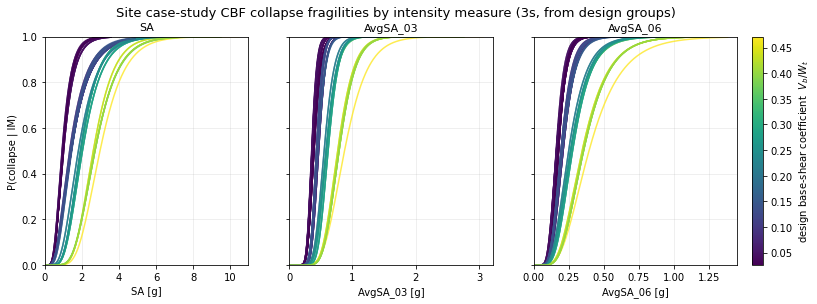

saved C:\Users\clemettn\Documents\phd\results\06_group_ida_femap695\ida_femap695_collapse_fragilities_by_im_5s.png


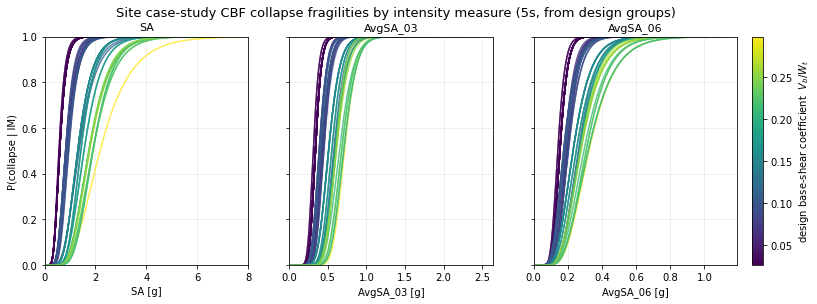

In [22]:
def plot_fragilities(n: int):
    keys = [k for k in sorted(site_results) if k[0] == n]
    if not keys:
        print(f"{n}s: nothing to plot")
        return None
    vbs = np.array([VB_COEFF.get(k, np.nan) for k in keys])
    norm = Normalize(vmin=np.nanmin(vbs), vmax=np.nanmax(vbs))
    cmap = cm.viridis

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
    for ax, im in zip(axes, IM_ORDER):
        for k in keys:
            frag = site_results[k][im]
            median_g = frag["median"]
            x = np.linspace(1e-3, median_g * 3.5, 400)
            y = lognorm.cdf(x, s=frag["dispersion"], scale=median_g)
            ax.plot(x, y, lw=1.5, alpha=0.8, color=cmap(norm(VB_COEFF.get(k, np.nan))))
        ax.set_title(im, fontsize=11)
        ax.set_xlabel(f"{im} [g]")
        ax.set_xlim(left=0)
        ax.set_ylim(0, 1)
        ax.grid(True, lw=0.5, alpha=0.4)
    axes[0].set_ylabel("P(collapse | IM)")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label(r"design base-shear coefficient  $V_b/W_t$")
    fig.suptitle(f"Site case-study CBF collapse fragilities by intensity measure "
                 f"({n}s, from design groups)", fontsize=13)
    fig_path = FIG_ROOT / f"{IDA_TAG}_collapse_fragilities_by_im_{n}s.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    print(f"saved {fig_path}")
    return fig


for n in STOREYS:
    if plot_fragilities(n) is not None:
        plt.show()

### Collapse median / dispersion vs design base-shear coefficient

Collapse median (in g) and dispersion $\beta$ against the design base-shear coefficient
$V_b/W_t$, one panel per intensity measure and one figure per storey count. Markers are
coloured by $V_b/W_t$ (same *viridis* scale) and joined in ascending order to show the
capacity trend.

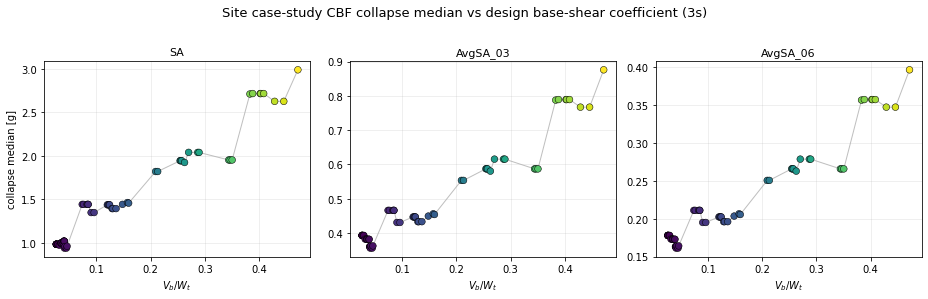

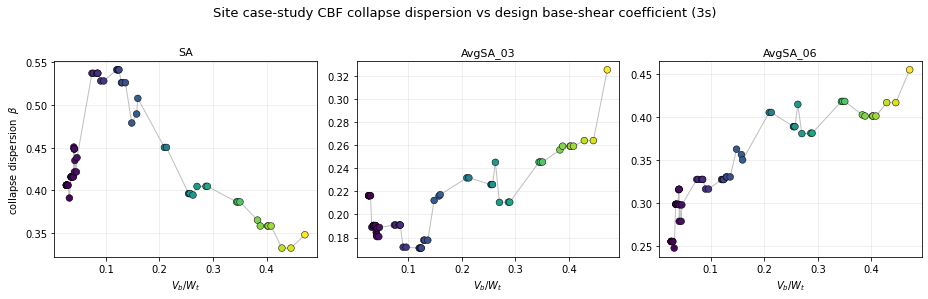

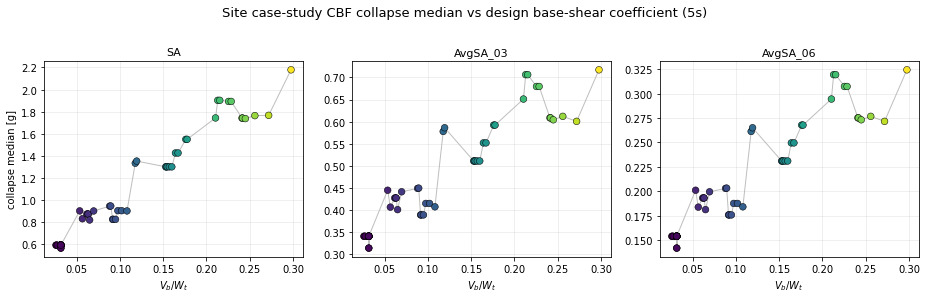

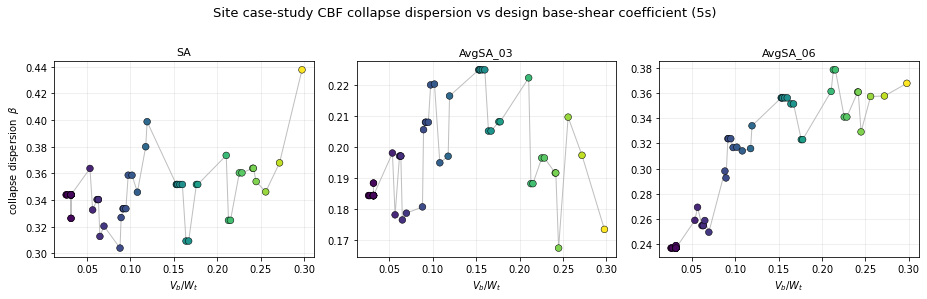

In [23]:
def plot_param_vs_vbcoeff(n: int, param: str, ylabel: str, title: str):
    """3-panel scatter of a fragility parameter ('median'/'dispersion') vs Vb_coeff."""
    keys = [k for k in sorted(site_results) if k[0] == n]
    if not keys:
        print(f"{n}s: nothing to plot")
        return None
    vbs = np.array([VB_COEFF.get(k, np.nan) for k in keys])
    order = np.argsort(vbs)
    vbs_s = vbs[order]
    norm = Normalize(vmin=np.nanmin(vbs), vmax=np.nanmax(vbs))
    cmap = cm.viridis

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True)
    for ax, im in zip(axes, IM_ORDER):
        vals = np.array([site_results[k][im][param] for k in keys])[order]
        ax.plot(vbs_s, vals, "-", color="0.75", lw=1, zorder=1)
        ax.scatter(vbs_s, vals, c=vbs_s, cmap=cmap, norm=norm,
                   s=45, edgecolor="k", linewidths=0.5, zorder=2)
        ax.set_title(im, fontsize=11)
        ax.set_xlabel(r"$V_b/W_t$")
        ax.grid(True, lw=0.5, alpha=0.4)
    axes[0].set_ylabel(ylabel)
    fig.suptitle(f"{title} ({n}s)", fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return fig


for n in STOREYS:
    fig_med = plot_param_vs_vbcoeff(
        n, "median", "collapse median [g]",
        "Site case-study CBF collapse median vs design base-shear coefficient")
    if fig_med is not None:
        fig_med.savefig(FIG_ROOT / f"collapse_median_vs_vbcoeff_{n}s.png",
                        dpi=200, bbox_inches="tight")
        plt.show()

    fig_disp = plot_param_vs_vbcoeff(
        n, "dispersion", r"collapse dispersion  $\beta$",
        "Site case-study CBF collapse dispersion vs design base-shear coefficient")
    if fig_disp is not None:
        fig_disp.savefig(FIG_ROOT / f"collapse_dispersion_vs_vbcoeff_{n}s.png",
                         dpi=200, bbox_inches="tight")
        plt.show()

## 10. Collapse-bracket variants: upper bound and geometric average

An IDA never observes the collapse intensity exactly. It brackets it: the highest
analysed intensity that ran to completion (`lb`, the top of the IDA curve and the
capacity every fragility above is fitted from) and the lowest that collapsed (`ub`).
Everything in between is unresolved, and the residual error is uniform in log space, so
the *geometric* mean `avg = sqrt(lb * ub)` is the bracket's log-midpoint - the estimate
with no expected error. Notebook 074 measures the consequence: `lb` puts the median
collapse capacity about 4.3% below the MSA, `ub` biases it upward, `avg` shows no
meaningful bias.

The bracket is read from the IDA's own run logs and applied to the **published**
AvgSA_03 capacities as a ratio:

    ub_AvgSA = lb_AvgSA * (ub_iml_SA / lb_iml_SA)

Collapse is a linearly scalable event, so the ratio between two intensities of the same
record is the same number in every intensity measure. Rescaling rather than re-converting
also means these tables cannot drift away from the published ones: the check below
asserts that the run log's `lb` run is exactly the run `get_collapse_iml` returned.

Written here, for AvgSA_03 only:

* `group_femap695_bracket_collapsefragility_summary.csv` - median and dispersion per
  design group, one column block per variant;
* `site_femap695_bracket_collapsefragility_summary.csv` - the same, fanned out to every
  member site (one row per structure);
* `group_femap695_collapse_imls_AvgSA_03_{ub,avg}.csv` - the group x record capacities
  the fits are built from, which is what nb 070 resamples.

No per-variant fragility JSONs and no per-site JSONs are written - nothing downstream
reads a fragility curve for these variants, only their parameters.


In [24]:
def bracket_from_run_logs(n: int, gid: int, ida_tag: str = IDA_TAG) -> pd.DataFrame:
    """Per-record collapse bracket, read from the IDA run logs.

    ``lb`` is the highest analysed intensity that did not collapse - the run the IDA
    curve ends on - and ``ub`` the lowest that did. Both IMLs are in the IDA's native
    SA(T1) units [mm/s^2]; the scale factors come along so the two can be cross-checked.
    Indexed by record tag, matching the keys of ``group_imls``.
    """
    logs = collect_record_logs(group_ida_folder(n, gid, ida_tag))
    name = group_folder_name(n, gid)

    rows = {}
    for tag, rec_log in logs.items():
        starts = rec_log["run_logs"]
        if len(starts) > 1:
            raise ValueError(f"{name} record {tag}: {len(starts)} starts, expected 1")
        runs = [v for k, v in starts["start_1"].items() if k.isnumeric()]
        no_collapse = [v for v in runs if not v["collapsed"]]
        collapse = [v for v in runs if v["collapsed"]]
        if not no_collapse or not collapse:
            raise ValueError(f"{name} record {tag}: bracket is one-sided "
                             f"({len(no_collapse)} stable, {len(collapse)} collapsed runs)")
        lb = max(no_collapse, key=lambda v: v["iml"])
        ub = min(collapse, key=lambda v: v["iml"])
        rows[tag] = {"lb_iml_SA": lb["iml"], "ub_iml_SA": ub["iml"],
                     "lb_sf": lb["scale_factor"], "ub_sf": ub["scale_factor"]}

    return pd.DataFrame.from_dict(rows, orient="index")


bracket_imls: dict[tuple[int, int], dict[str, pd.Series]] = {}
bracket_fits: dict[tuple[int, int], dict[str, tuple[float, float]]] = {}
bracket_widths = {}

for (n, gid), d in sorted(group_imls.items()):
    if BRACKET_IM not in d:
        print(f"[skip] {group_folder_name(n, gid)}: no {BRACKET_IM} capacities")
        continue
    name = group_folder_name(n, gid)
    lb = pd.Series(d[BRACKET_IM], dtype=float).sort_index()       # [g]
    br = bracket_from_run_logs(n, gid).reindex(lb.index)

    if br.isna().any().any():
        raise ValueError(f"{name}: no run log for records "
                         f"{list(br.index[br.isna().any(axis=1)])}")
    if not (br["ub_iml_SA"] > br["lb_iml_SA"]).all():
        raise ValueError(f"{name}: ub is not above lb for every record")

    # The assumption the whole rescaling rests on: the capacity the published fragility
    # was fitted from IS the lower bound of the bracket. get_collapse_iml returns the top
    # of the IDA curve, so it must equal the run log's highest non-collapsing IML.
    published_sa = pd.Series(d["SA"], dtype=float).reindex(lb.index) * GRAVITY
    if not np.allclose(published_sa, br["lb_iml_SA"], rtol=1e-8):
        off = (published_sa / br["lb_iml_SA"] - 1).abs()
        msg = (f"{name}: published SA capacity is not the run log's lower bound "
               f"(max |rel. diff| {off.max():.2e} at record {off.idxmax()})")
        if STRICT:
            raise ValueError(msg)
        print(f"WARNING: {msg}")

    ratio = br["ub_iml_SA"] / br["lb_iml_SA"]
    # the same ratio in scale-factor space, as an independent read of the same bracket
    if not np.allclose(ratio, br["ub_sf"] / br["lb_sf"], rtol=1e-8):
        raise ValueError(f"{name}: IML and scale-factor brackets disagree")

    ub = lb * ratio
    variants = {"ub": ub, "avg": np.sqrt(lb * ub)}
    bracket_imls[(n, gid)] = {v: variants[v] for v in BRACKET_VARIANTS}
    bracket_fits[(n, gid)] = {v: tuple(lognorm_moment_fit(list(variants[v])))
                              for v in BRACKET_VARIANTS}
    bracket_widths[name] = float(np.log(ratio).mean())

    lb_median, _ = lognorm_moment_fit(list(lb))
    detail = "  ".join(f"{BRACKET_LABEL[v]}: median={bracket_fits[(n, gid)][v][0]:.4f} "
                       f"({bracket_fits[(n, gid)][v][0] / lb_median - 1:+.1%} on lb), "
                       f"beta={bracket_fits[(n, gid)][v][1]:.4f}"
                       for v in BRACKET_VARIANTS)
    print(f"[ok]   {name}: lb median={lb_median:.4f}  {detail}")

_widths = pd.Series(bracket_widths)
print(f"\n{len(bracket_fits)} groups bracketed. Mean log bracket width ln(ub/lb): "
      f"{_widths.mean():.4f} (min {_widths.min():.4f}, max {_widths.max():.4f}) "
      f"-> {np.exp(_widths.mean()):.4f} in real units")


[ok]   group_3s_00: lb median=0.3931  AvgSA_03_ub: median=0.4242 (+7.9% on lb), beta=0.2156  AvgSA_03_avg: median=0.4084 (+3.9% on lb), beta=0.2154
[ok]   group_3s_01: lb median=0.3820  AvgSA_03_ub: median=0.4124 (+8.0% on lb), beta=0.1820  AvgSA_03_avg: median=0.3969 (+3.9% on lb), beta=0.1857
[ok]   group_3s_02: lb median=0.3825  AvgSA_03_ub: median=0.4140 (+8.2% on lb), beta=0.1849  AvgSA_03_avg: median=0.3980 (+4.0% on lb), beta=0.1865
[ok]   group_3s_03: lb median=0.4662  AvgSA_03_ub: median=0.5027 (+7.8% on lb), beta=0.1822  AvgSA_03_avg: median=0.4841 (+3.8% on lb), beta=0.1859
[ok]   group_3s_04: lb median=0.3602  AvgSA_03_ub: median=0.3932 (+9.2% on lb), beta=0.1812  AvgSA_03_avg: median=0.3764 (+4.5% on lb), beta=0.1813
[ok]   group_3s_05: lb median=0.3623  AvgSA_03_ub: median=0.3905 (+7.8% on lb), beta=0.1762  AvgSA_03_avg: median=0.3761 (+3.8% on lb), beta=0.1813
[ok]   group_3s_06: lb median=0.3563  AvgSA_03_ub: median=0.3841 (+7.8% on lb), beta=0.1735  AvgSA_03_avg: media

In [25]:
# Group summary - the same two-row (IM, parameter) header and ("info", "sites") column
# as GROUP_SUMMARY_CSV, so nb 070 reads this file with the loaders it already has.
bracket_group_rows = {}
for (n, gid), fits in sorted(bracket_fits.items()):
    row = {("info", "storeys"): n,
           ("info", "n_sites"): len(members[(n, gid)]),
           ("info", "sites"): " ".join(str(s) for s in members[(n, gid)])}
    for v in BRACKET_VARIANTS:
        row[(BRACKET_LABEL[v], "median")] = fits[v][0]
        row[(BRACKET_LABEL[v], "dispersion")] = fits[v][1]
    bracket_group_rows[group_folder_name(n, gid)] = row

bracket_group_summary = pd.DataFrame.from_dict(bracket_group_rows, orient="index")
if bracket_group_summary.empty:
    print("no groups bracketed - no bracket group summary written")
else:
    bracket_group_summary.columns = pd.MultiIndex.from_tuples(
        bracket_group_summary.columns, names=["IM", "parameter"])
    bracket_group_summary = bracket_group_summary[
        ["info"] + [BRACKET_LABEL[v] for v in BRACKET_VARIANTS]]
    bracket_group_summary.index.name = "group"
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(bracket_group_summary.to_string())
    bracket_group_summary.to_csv(BRACKET_GROUP_SUMMARY_CSV)
    print(f"\nwrote {BRACKET_GROUP_SUMMARY_CSV}")


IM             info                                                                AvgSA_03_ub            AvgSA_03_avg           
parameter   storeys n_sites                                                  sites      median dispersion       median dispersion
group                                                                                                                            
group_3s_00       3       8                                   0 4 8 19 25 26 27 29       0.424      0.216        0.408      0.215
group_3s_01       3       6                                          1 2 5 6 16 23       0.412      0.182        0.397      0.186
group_3s_02       3       1                                                      3       0.414      0.185        0.398      0.187
group_3s_03       3       5                                          7 10 11 18 24       0.503      0.182        0.484      0.186
group_3s_04       3       3                                                9 20 22       0

In [26]:
# Fan out to sites. Sites sharing a design group share its IDA, so they share its
# parameters exactly - as in section 7, the duplication is the point. Only this summary
# is written; no per-site fragility JSON exists for the bracket variants.
bracket_site_rows = {}
for (n, gid), fits in sorted(bracket_fits.items()):
    for site in members[(n, gid)]:
        row = {("info", "storeys"): n, ("info", "site"): site,
               ("info", "group"): group_folder_name(n, gid),
               ("info", "Vb_coeff"): VB_COEFF.get((n, site), np.nan)}
        for v in BRACKET_VARIANTS:
            row[(BRACKET_LABEL[v], "median")] = fits[v][0]
            row[(BRACKET_LABEL[v], "dispersion")] = fits[v][1]
        bracket_site_rows[structure_tag(n, site)] = row

bracket_site_summary = pd.DataFrame.from_dict(bracket_site_rows, orient="index")
if bracket_site_summary.empty:
    print("no groups bracketed - no bracket site summary written")
else:
    bracket_site_summary.columns = pd.MultiIndex.from_tuples(
        bracket_site_summary.columns, names=["IM", "parameter"])
    bracket_site_summary = bracket_site_summary[
        ["info"] + [BRACKET_LABEL[v] for v in BRACKET_VARIANTS]]
    bracket_site_summary.index.name = "structure"
    bracket_site_summary = bracket_site_summary.sort_values(
        [("info", "storeys"), ("info", "Vb_coeff")])
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(bracket_site_summary.to_string())
    bracket_site_summary.to_csv(BRACKET_SITE_SUMMARY_CSV)
    print(f"\nwrote {BRACKET_SITE_SUMMARY_CSV}  "
          f"({len(bracket_site_summary)} structures)")


IM                   info                            AvgSA_03_ub            AvgSA_03_avg           
parameter         storeys site        group Vb_coeff      median dispersion       median dispersion
structure                                                                                          
3s_cbf_dc2_site4        3    4  group_3s_00    0.026       0.424      0.216        0.408      0.215
3s_cbf_dc2_site29       3   29  group_3s_00    0.026       0.424      0.216        0.408      0.215
3s_cbf_dc2_site8        3    8  group_3s_00    0.026       0.424      0.216        0.408      0.215
3s_cbf_dc2_site19       3   19  group_3s_00    0.026       0.424      0.216        0.408      0.215
3s_cbf_dc2_site27       3   27  group_3s_00    0.026       0.424      0.216        0.408      0.215
3s_cbf_dc2_site26       3   26  group_3s_00    0.026       0.424      0.216        0.408      0.215
3s_cbf_dc2_site0        3    0  group_3s_00    0.029       0.424      0.216        0.408      0.215


In [27]:
# Per-record capacity tables, one per variant, in g - the same layout as section 8.
# These are what nb 070 bootstraps: it resamples records, so it needs the matrix, not
# just the fit.
bracket_iml_tables: dict[str, pd.DataFrame] = {}
for v in BRACKET_VARIANTS:
    rows = {group_folder_name(n, gid): d[v]
            for (n, gid), d in sorted(bracket_imls.items())}
    if not rows:
        print(f"{BRACKET_LABEL[v]}: no groups bracketed - no capacity table written")
        continue
    df = pd.DataFrame.from_dict(rows, orient="index").reindex(columns=RECORD_TAGS)
    df.index.name = "group"
    df.columns.name = "record"
    bracket_iml_tables[v] = df
    df.to_csv(BRACKET_IML_CSV[v])
    print(f"wrote {BRACKET_IML_CSV[v]}  ({df.shape[0]} groups x {df.shape[1]} records)")

if bracket_iml_tables:
    counts = bracket_iml_tables[BRACKET_VARIANTS[0]].notna().sum(axis=1)
    short_rows = counts[counts != N_EXPECTED_RECORDS]
    if len(short_rows):
        print(f"\nWARNING: {len(short_rows)} group(s) have fewer than "
              f"{N_EXPECTED_RECORDS} records:")
        for g, c in short_rows.items():
            print(f"  {g}: {int(c)} records")

    with pd.option_context("display.float_format", lambda v: f"{v:.3f}",
                           "display.max_columns", None, "display.width", 200):
        for v, df in bracket_iml_tables.items():
            print(f"\n{BRACKET_LABEL[v]} collapse capacities [g] (first 5 groups):")
            print(df.head().to_string())


wrote C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups\group_femap695_collapse_imls_AvgSA_03_ub.csv  (51 groups x 22 records)
wrote C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_design_groups\group_femap695_collapse_imls_AvgSA_03_avg.csv  (51 groups x 22 records)

AvgSA_03_ub collapse capacities [g] (first 5 groups):
record          0     1    10    11    12    13    14    15    16    17    18    19     2    20    21     3     4     5     6     7     8     9
group                                                                                                                                          
group_3s_00 0.347 0.404 0.321 0.525 0.573 0.473 0.515 0.347 0.545 0.344 0.323 0.430 0.507 0.334 0.634 0.462 0.338 0.409 0.577 0.378 0.360 0.402
group_3s_01 0.353 0.359 0.347 0.468 0.410 0.534 0.555 0.404 0.542 0.365 0.347 0.442 0.393 0.346 0.501 0.329 0.300 0.400 0.562 0.399 0.422 0.442
group_3s_02 0.330 0.399 